In [160]:
import math


class Value:
    def __init__(self, data, _children=(), _op="", label=""):
        self.data = data
        self.grad = 0.0
        self._backward = lambda: None
        self._prev = _children
        self._op = _op
        self.label = label

    def __repr__(self):
        return f"Value(data={self.data})"

    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, _children=(self, other), _op="+")

        def _backward():
            self.grad += out.grad
            other.grad += out.grad

        out._backward = _backward
        return out

    def __radd__(self, other):
        return self + other

    def __neg__(self):
        return -1 * self

    def __sub__(self, other):
        return self + -other

    def __rsub__(self, other):
        return self - other

    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, _children=(self, other), _op="*")

        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad

        out._backward = _backward
        return out

    def __rmul__(self, other):
        return self * other

    def __pow__(self, other):
        assert isinstance(other, (int, float))
        out = Value(self.data**other, _children=(self,), _op=f"**{other}")

        def _backward():
            self.grad = other * self.data ** (other - 1) * out.grad

        out._backward = _backward
        return out

    def __truediv__(self, other):
        return self * (other**-1)

    def tanh(self):
        x = self.data
        t = (math.exp(2 * x) - 1) / (math.exp(2 * x) + 1)
        out = Value(t, _children=(self,), _op="tanh")

        def _backward():
            self.grad += (1 - t**2) * out.grad

        out._backward = _backward
        return out

    def relu(self):
        x = self.data
        out = Value(x if self.data >= 0 else 0, _children=(self,), _op="relu")

        def _backward():
            self.grad += (1 if x >= 0 else 0) * out.grad

        out._backward = _backward
        return out

    def sigmoid(self):
        x = self.data
        s = 1 / (1 + math.exp(-x))
        out = Value(s, _children=(self,), _op="sigmoid")

        def _backward():
            self.grad += s * (1 - s) * out.grad

        out._backward = _backward
        return out

    def backward(self):
        topo = []
        visited = set()

        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)

        build_topo(self)
        self.grad = 1.0
        for node in reversed(topo):
            node._backward()

In [161]:
import matplotlib.pyplot as plt
import numpy as np

In [162]:
# inputs
x1 = Value(2.0, label="x1")
x2 = Value(0.0, label="x2")
# wieghts
w1 = Value(-3.0, label="w1")
w2 = Value(1.0, label="w2")
# bias
b = Value(6.8, label="b")

x1w1 = x1 * w1
x1w1.label = "x1w1"
x2w2 = x2 * w2
x2w2.label = "x2w2"
x1w1x2w2 = x1w1 + x2w2
x1w1x2w2.label = "x1w1x2w2"
n = x1w1x2w2 + b
n.label = "n"
o = n.tanh()
o.label = "output"
o.backward()

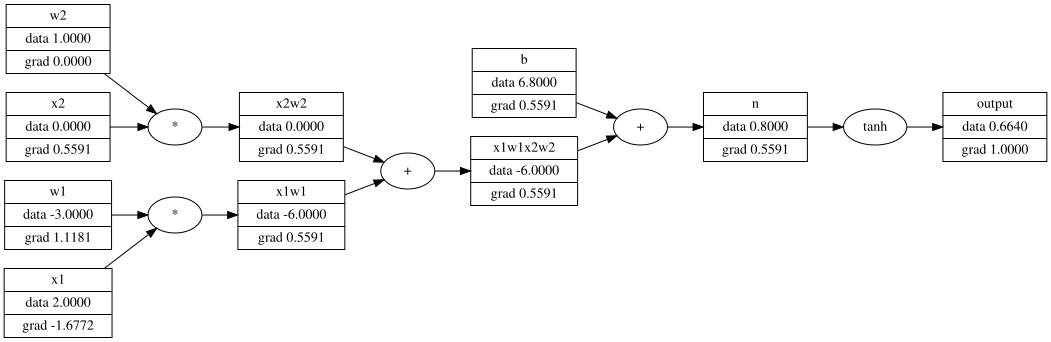

In [163]:
draw_dot(o)

In [164]:
import random


class Neuron:
    def __init__(self, nin):
        self.w = [Value(random.uniform(-1, 1)) for _ in range(nin)]
        self.b = Value(random.uniform(-1, 1))

    def __call__(self, x):
        act = sum((wi * xi for wi, xi in zip(self.w, x)), self.b)
        out = act.tanh()
        return out

    def parameters(self):
        return self.w + [self.b]


class Layer:
    def __init__(self, nin, nout):
        self.neurons = [Neuron(nin) for _ in range(nout)]

    def __call__(self, x):
        outs = [n(x) for n in self.neurons]
        return outs[0] if len(outs) == 1 else outs

    def parameters(self):
        return [p for neuron in self.neurons for p in neuron.parameters()]


class MLP:
    def __init__(self, nin, nouts):
        sz = [nin] + nouts
        self.layers = [Layer(sz[i], sz[i + 1]) for i in range(len(nouts))]

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x

    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]

    def train(self, xs, ys, epochs=500, lr=0.01):
        for k in range(epochs):
            ypred = [self(x) for x in xs]
            loss = sum((ygt - yout) ** 2 for ygt, yout in zip(ys, ypred))

            for p in self.parameters():
                p.grad = 0.0

            loss.backward()

            for p in self.parameters():
                p.data += -lr * p.grad

            if k % 50 == 0:
                print(k, loss.data)

        return loss

In [169]:
xs = [
    [2.0, 3.0, -1.0],
    [3.0, -1.0, 0.5],
    [0.5, 1.0, 1.0],
    [1.0, 1.0, -1.0],
]
ys = [1.0, -1.0, -1.0, 1.0]

n = MLP(3, [4, 4, 1])
n1 = Neuron(3)
n1(xs[0])
n1.parameters()

[Value(data=0.36589727518748005),
 Value(data=0.2999656134938553),
 Value(data=0.9966985608754608),
 Value(data=-0.5943601776446523)]

In [171]:
n.train(xs, ys, epochs=500, lr=100)

OverflowError: math range error

In [167]:
y_pred = [n(x) for x in xs]
y_pred

[Value(data=-1.0), Value(data=-1.0), Value(data=-1.0), Value(data=-1.0)]